# Phase 0 — Baselines: what must every model beat?

**Before any model: how well do naive, points-only predictors rank next-gameweek returns, within each position?**

_Read-only benchmark — Phase 0 of [docs/predictive-layer-plan.md](../../docs/predictive-layer-plan.md). No model here; this fixes the floor every later model is measured against._
Population: `minutes > 0`, **DGW excluded**, evaluate GW > 3; expanding-window walk-forward, leakage-checked.

> **How to read.** Each baseline predicts a player's points from that player's **strictly-prior** gameweeks only (leakage-safe). We score **ranking**, not exact points, because FPL is won by ranking players and the target is zero-inflated/right-skewed.

> **Ranking is within-position only.** Squads fill under position quotas (2 GK / 5 DEF / 5 MID / 3 FWD), so ranking a keeper against a forward is meaningless — **cross-position pooling is abolished**. Metrics: within-(GW, position) **Spearman**, tie-aware **precision@k**, **NDCG@k** (k scaled per position); MAE is a secondary sanity number; RMSE is omitted (haul-dominated).

> **Conditional on appearance.** Metrics cover players who *actually featured* — availability is treated as known. This is *ranking given the player played*, a valid sub-problem, **not** end-to-end forecast accuracy (predicting who plays is the availability family's job).

## Setup
> Load the mart, apply the population filter, and pull the two harness views: the within-position summary and the per-position detail. All numbers come from `model.eval` — the notebook only renders them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError
from model.eval import walk_forward_baselines, walk_forward_by_position
from model.eval.walkforward import POSITIONS

BASELINE_COLOUR = {
    'expanding season avg': '#1f77b4', 'rolling avg (5)': '#2ca02c', 'rolling avg (3)': '#98df8a',
    'last-GW points': '#ff7f0e', 'position mean (sanity floor)': '#bdbdbd',
}

try:
    loaded = load_mart()
except (MartNotBuiltError, MartSchemaError) as err:
    print(f'Rebuilding mart ({type(err).__name__})...')
    run_pipeline(force=True)
    loaded = load_mart()
mart = loaded.mart

summary = walk_forward_baselines(mart)
by_pos = walk_forward_by_position(mart)
print(f'Study range: GW 1 - {loaded.data_cutoff_gw} | minutes > 0 | DGW excluded | common eval n = {int(summary["n"].iloc[0]):,}')

Study range: GW 1 - 38 | minutes > 0 | DGW excluded | common eval n = 8,728


## (a) Within-position summary — which naive predictor ranks best?
> One line per baseline: `spearman_pos` is the mean within-(GW, position) rank correlation (there is **no** cross-position number). The **season average wins** — a player's cumulative level is the strongest simple signal (*level persists*), while chasing last week (*last-GW*) is worst (*deviations mean-revert*). The identity-free **position mean is NaN** here — it is constant within a position, so it cannot rank at all, confirming the signal is player identity.

,spearman_pos,mae,n,coverage
baseline,,,,
expanding season avg,0.2049,2.1931,8728,0.984
rolling avg (5),0.2016,2.2835,8728,0.849
rolling avg (3),0.1765,2.3778,8728,0.940
last-GW points,0.1632,2.7030,8728,0.984
position mean (sanity floor),NaN,2.2287,8728,1.000


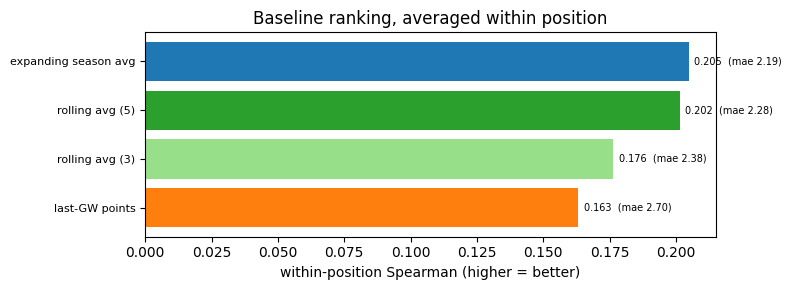

In [2]:
display(summary.round(4))

s = summary['spearman_pos'].dropna().sort_values()
fig, ax = plt.subplots(figsize=(8, 3.0))
ax.barh(np.arange(len(s)), s.values, color=[BASELINE_COLOUR[b] for b in s.index])
for i, b in enumerate(s.index):
    ax.text(s[b] + 0.002, i, f"{s[b]:.3f}  (mae {summary.loc[b,'mae']:.2f})", va='center', fontsize=7)
ax.set_yticks(np.arange(len(s))); ax.set_yticklabels(s.index, fontsize=8)
ax.set_xlabel('within-position Spearman (higher = better)'); ax.axvline(0, color='k', lw=0.5)
ax.set_title('Baseline ranking, averaged within position')
plt.tight_layout(); plt.show()

## (b) Per-position benchmark — the real bars to beat
> The summary above averages over positions and hides a ~5x spread. **GK is near chance** (clean-sheet/fixture driven, not player persistence — echoing the diagnostic layer's GK abstentions). **MID and FWD are the rankable positions**; FWD is the one place recent form (**rolling-5**) beats season class. These per-position bars — not any pooled number — gate Phase 1.

spearman  precision_at_k  ndcg_at_k  \
position baseline                                                            
GK       rolling avg (5)                 0.0619          0.2803     0.4299   
         last-GW points                  0.0352          0.2576     0.4127   
         rolling avg (3)                 0.0349          0.2879     0.4400   
         expanding season avg            0.0236          0.3258     0.4573   
         position mean (sanity floor)       NaN             NaN        NaN   
DEF      expanding season avg            0.1671          0.3500     0.4383   
         rolling avg (5)                 0.1312          0.3242     0.4191   
         rolling avg (3)                 0.1015          0.3076     0.3889   
         last-GW points                  0.0829          0.2788     0.3685   
         position mean (sanity floor)       NaN             NaN        NaN   
MID      expanding season avg            0.3114          0.2985     0.4414   
         rolling avg (5)                 0.2793          0.2864     0.4209   
         rolling avg (3)                 0.2691          0.2515     0.4084   
         last-GW points                  0.2450          0.2394     0.3849   
         position mean (sanity floor)       NaN             NaN        NaN   
FWD      rolling avg (5)                 0.3339          0.4811     0.4869   
         expanding season avg            0.3175          0.4811     0.4946   
         rolling avg (3)                 0.3005          0.4659     0.4692   
         last-GW points                  0.2895          0.4659     0.4535   
         position mean (sanity floor)       NaN             NaN        NaN   

                                        k  n_gw  
position baseline                                
GK       rolling avg (5)                4    33  
         last-GW points                 4    33  
         rolling avg (3)                4    33  
         expanding season avg           4    33  
         position mean (sanity floor)   4    33  
DEF      expanding season avg          20    33  
         rolling avg (5)               20    33  
         rolling avg (3)               20    33  
         last-GW points                20    33  
         position mean (sanity floor)  20    33  
MID      expanding season avg          20    33  
         rolling avg (5)               20    33  
         rolling avg (3)               20    33  
         last-GW points                20    33  
         position mean (sanity floor)  20    33  
FWD      rolling avg (5)                8    33  
         expanding season avg           8    33  
         rolling avg (3)                8    33  
         last-GW points                 8    33  
         position mean (sanity floor)   8    33

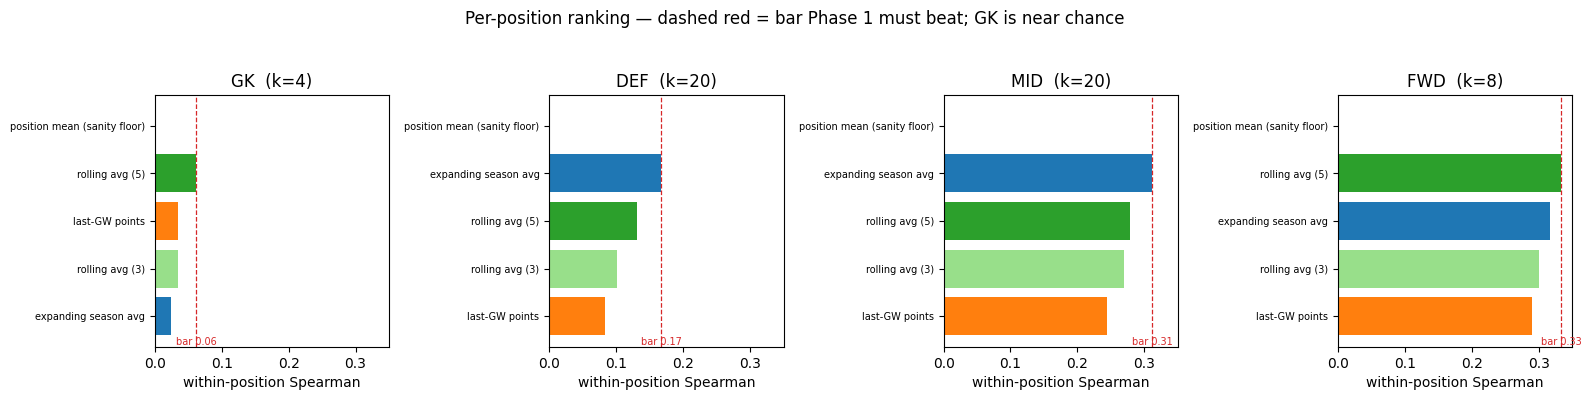

In [3]:
display(by_pos.round(4))

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), sharex=True)
for ax, pos in zip(axes, POSITIONS):
    sub = by_pos.xs(pos, level='position').sort_values('spearman')
    labels = sub.index
    ax.barh(np.arange(len(labels)), sub['spearman'].fillna(0.0), color=[BASELINE_COLOUR[b] for b in labels])
    best = sub['spearman'].max()
    ax.axvline(best, color='#d62728', ls='--', lw=0.9)
    ax.text(best, -0.6, f'bar {best:.2f}', color='#d62728', fontsize=7, ha='center')
    ax.set_yticks(np.arange(len(labels))); ax.set_yticklabels(labels, fontsize=7)
    ax.set_title(f'{pos}  (k={int(sub["k"].iloc[0])})'); ax.axvline(0, color='k', lw=0.5)
    ax.set_xlabel('within-position Spearman')
fig.suptitle('Per-position ranking — dashed red = bar Phase 1 must beat; GK is near chance', y=1.04)
plt.tight_layout(); plt.show()

## Summary — the bars Phase 1 must beat

| position | bar (within-position Spearman) | read |
|---|---|---|
| GK | ~0.06 | near chance — history barely ranks keepers |
| DEF | 0.17 | middling |
| MID | 0.31 | rankable |
| FWD | 0.33 | most rankable; rolling-5 > season-avg |

**What it establishes.** *Level persists* (season avg best), *deviations mean-revert* (last-GW worst, smoothing helps), *identity dominates* (position-only cannot rank within position — corroborates Q1b). The frozen numbers live in [docs/studies/results/predictive-phase0-baselines.md](../../docs/studies/results/predictive-phase0-baselines.md).

**Gate.** A Phase-1 model earns promotion only by beating these **per-position** bars on this same walk-forward harness. There is no pooled number to game.